In [1]:
import xarray as xr
import scipy
import numpy as np
import pandas as pd
import copy
from datetime import datetime
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import pandas as pd
import numpy as np
from scipy.sparse import diags
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import numpy as np
import pandas as pd
from typing import Tuple
import torch
from sklearn.linear_model import LinearRegression
import proto_scales.data_prep.prepare_data as prep
import pickle

In [2]:

def fit_control_mahalanobis(u_train_norm, eps=1e-6):
    """
    u_train_norm: [N, T, Du] standardized using train-only scaler
    Returns mu [Du], inv_cov [Du, Du]
    """
    U = u_train_norm.reshape(-1, u_train_norm.shape[-1])  # [N*T, Du]
    mu = U.mean(axis=0)
    cov = np.cov(U.T) + eps * np.eye(U.shape[1])
    inv_cov = np.linalg.inv(cov)
    return mu.astype(np.float32), inv_cov.astype(np.float32)

def mahalanobis_score(u_fut_norm, mu, inv_cov):
    """
    u_fut_norm: [B, H, Du] standardized
    returns score: [B, H] (per-step)
    """
    diff = u_fut_norm - mu[None, None, :]
    # score[b,h] = diff^T inv_cov diff
    return np.einsum("bhd,dd,bhd->bh", diff, inv_cov, diff)

def pick_threshold_from_val(val_loader, mu, inv_cov, percentile=99.0):
    all_scores = []
    for _, _,_, u_fut,_, _ in val_loader:
        #s = mahalanobis_score(u_fut.numpy(), mu, inv_cov)  # [B,H]
        s = mahalanobis_score(u_fut, mu, inv_cov)  # [B,H]
        all_scores.append(s.reshape(-1))
    all_scores = np.concatenate(all_scores)
    return float(np.percentile(all_scores, percentile))


def gate_from_score(score_bh, tau, k=5.0):
    """
    score_bh: torch tensor [B,H]
    returns w: [B,H,1]
    """
    w = torch.sigmoid(k * (tau - score_bh))
    return w.unsqueeze(-1)


In [3]:
@torch.no_grad()
def forecast_with_u_fallback(model, y_ctx, u_ctx, u_fut, mu_u, inv_cov_u, tau, use_linear_model = True, n_samples = 50,k=5.0):
    """
    y_ctx: [B,Tc,Dy] (normalized)
    u_ctx: [B,Tc,Du] (normalized)
    u_fut: [B,H,Du]  (normalized)
    mu_u:  [Du] numpy or torch
    inv_cov_u: [Du,Du] numpy or torch
    """
    device = y_ctx.device
    B, H, Du = u_fut.shape

    # DeepSSM mean forecast (IMPORTANT: mean, no observation noise)
    y_ssm, _, _,pr_ssm,_,_ = model.forecast(y_ctx, u_ctx, u_fut, steps=H, n_samples=n_samples)  # [B,H,Dy]
    # If your forecast adds obs noise, remove it for MSE evaluation.

    # Linear fallback
    if(use_linear_model):
        y_lin = model.ctrl_lin(u_fut.reshape(-1, Du)).reshape(B, H, -1)
    else:
        y_lin = y_ssm

    # Control OOD score (Mahalanobis)
    mu_u_t = torch.as_tensor(mu_u, device=device)
    inv_t  = torch.as_tensor(inv_cov_u, device=device)

    diff = u_fut - mu_u_t[None, None, :]
    score = torch.einsum("bhd,dd,bhd->bh", diff, inv_t, diff)  # [B,H]

    # Gate + blend
    w = gate_from_score(score, tau=tau, k=k)  # [B,H,1]
    y_mix = w * y_ssm + (1.0 - w) * y_lin

    return y_mix, y_ssm, y_lin, pr_ssm, score, w

In [4]:
from proto_scales.ssm_model.scales_ssm import StandardScaler

#scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/training_3Apr26/" # good training, before Easter training
#scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260403_211718/" #all datasets
#scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260404_143034/" # no ssp585


# from proto_scales.ssm_model.scales_ssm_z2pr_sas_tas_full_norm import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260414_021217/" # all datasets, 500 Epochs, large z space
# zdim = 32 #24
# rnn_hidden=62
# use_linear_model = True
# emission_uses_u = False

# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260415_222153/" #all datasets, 500 Epochs
# zdim = 64

# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260416_114250/"
# zdim = 64
# rnn_hidden=62

#Use that to show old version
# from proto_scales.ssm_model.scales_ssm_z2pr_sas_tas_full_norm import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260416_181123/"
# model_filename = scaler_path+"model_out"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u = False

# #from proto_scales.ssm_model.scales_ssm_z2pr_sas_tas_full_norm import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260417_110635/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = False

# #from proto_scales.ssm_model.scales_ssm_z2pr_sas_tas_full_norm import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260417_171216/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True

# #from proto_scales.ssm_model.scales_ssm_z2pr_sas_tas_full_norm import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260417_230716/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True

# #from proto_scales.ssm_model.scales_ssm_z2pr_sas_tas_full_norm import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260418_123324/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =False

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260419_092632/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260420_021111/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260420_221205/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True

#The best so far
# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path = "/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260422_161603/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim=2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260424_090127/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3
#alpha_max = 0.1

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260425_230933/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260426_163558/"
# zdim = 32
# rnn_hidden=64
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 1


# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260427_031918/"
# zdim = 32
# rnn_hidden=64
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260427_172519/"
# zdim = 32
# rnn_hidden=64
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 4

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260427_170124/"
# zdim = 32
# rnn_hidden=64
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260428_023515/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

#This is much better than with resevoir_dim=6! Not so bad this one. 
# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260428_143351/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260428_143056/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 6

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260429_001324/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3


# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowResevoir import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260429_151747/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

#This is the first one with the hidden state in the resevoir. Still only trained with 100 context and 100 horizon
# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowHiddenRes import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260430_042523/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowHiddenRes import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260501_050145/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowHiddenRes import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260501_152847/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 3

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowHiddenRes import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260502_085041/"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowHiddenRes import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260504_173446/"
#model_filename = scaler_path+"model_out"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 2


# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_laggingGMT_slowHiddenRes import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260505_065731/checkpoints/"
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260506_100703/"
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260506_143413/"
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260506_164009/"
# model_filename = scaler_path+"checkpoints/model_epoch0010.pt"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 2


# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260506_180944/" #this one was not good at all, did not have uh_t
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260507_072522/" #Not bad, started again with training from scales_20260505_065731
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# resevoir_dim = 2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260508_123620/"
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt"
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
#alpha_max = 0.02
# resevoir_dim = 3

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260511_081617/" #Can do SOO 534-over really well for 0010
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
#alpha_max = 0.02
# resevoir_dim = 2
#Was used to create analysis data

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260512_143221/" 
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4


# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260513_145247/" 
# model_filename = scaler_path+"checkpoints/model_epoch0350.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260514_091200/"
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 2

# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260514_171221/"
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4
# #Was used to create analysis data

#Fine tuned on CanESM, only 10 epochs
# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260519_143746/"
# model_filename = scaler_path+"checkpoints/model_epoch0010.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4

#Fine tuned on CanESM, only 50 epochs
# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260520_103139/"
# model_filename = scaler_path+"checkpoints/model_epoch0050.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4

#First MAML training: only four models. 100 epochs
# from proto_scales.ssm_model.scales_ssm_z2tasAndpr_hysteresis import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_maml_20260528_140312/"
# model_filename = scaler_path+"checkpoints/meta_epoch0100.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4

#First training: ACCESS only, 500 epochs with correlated tas emission model. rank = 5, Here U stayed zero.
# from proto_scales.ssm_model.scales_ssm_tas_pr_hyst_correlated import DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260716_074330/"
# model_filename = scaler_path+"checkpoints/model_epoch0500.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4

from proto_scales.ssm_model.scales_ssm_tas_pr_hyst_correlated import DeepSSMPatternConditioned
scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_20260720_111724/"
model_filename = scaler_path+"checkpoints/model_epoch0480.pt" 
zdim = 64
rnn_hidden=256
use_linear_model = True
emission_uses_u =True
alpha_max = 0.002
resevoir_dim = 4





scaler_pickle_y_scaler_filename = scaler_path+"y_scaler.out"
scaler_pickle_u_scaler_filename = scaler_path+"u_scaler.out"
scaler_pickle_pr_scaler_filename = scaler_path+"pr_scaler.out"

y_scaler = StandardScaler.from_file(scaler_pickle_y_scaler_filename)
u_scaler = StandardScaler.from_file(scaler_pickle_u_scaler_filename)
pr_scaler = StandardScaler.from_file(scaler_pickle_pr_scaler_filename)

In [5]:
MODEL = 'ACCESS-ESM1-5'#'MPI-ESM1-2-LR'#'ACCESS-ESM1-5'#'CanESM5'
INDICATORS = ['tas','pr']
TEST_SCENARIOS = ['ssp245']
TRAIN_SCENARIOS = [ 'ssp585','1pctco2']#,'ssp534-over','flat10cdrincspinoff','ssp126','flat10zecincspinoff', 'flat10cdrincspinoff']#,'abrupt4xco2','ssp119','ssp460','ssp370']
N = 200 
PATTERN_SCALING_RESIDUALS = False
RAMP_DOWN_CORRECTED_PS = False
monthly_flag = True
use_smoothing = False
train_pattern_scaling_name = 'ssp585'

MODEL_PATH = f'/projects/icigroup/CMIP6/cmip6-ng-inc-oceans/{MODEL}'

In [6]:
train_data_shuffled = prep.fetch_and_shuffle_data(
    model_path=MODEL_PATH,
    indicators=INDICATORS,
    train_scenarios=TRAIN_SCENARIOS,
    monthly_flag=monthly_flag,
    use_smoothing=use_smoothing,
    train_pattern_scaling_name=train_pattern_scaling_name,
    pattern_scaling_residuals=PATTERN_SCALING_RESIDUALS,
    ramp_down_corrected_ps=RAMP_DOWN_CORRECTED_PS,
    sample_length=N,
    n_skip = 100  
)

u = train_data_shuffled[0][0,:].T[..., None]
y = np.transpose(train_data_shuffled[0][:,:],(2, 1, 0))
y = y[:,:,1:]
print(len(y))
regions = int(y.shape[-1]/2)
tas = y[:,:,:regions]
pr = y[:,:,-regions:]

N = y.shape[0]
idx = np.random.permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = idx[:n_train], idx[n_train:]

tas_tr, pr_tr, u_tr = tas[tr_idx],pr[tr_idx], u[tr_idx]
tas_va, pr_va, u_va = tas[va_idx],pr[va_idx], u[va_idx]

from proto_scales.ssm_model.scales_ssm import UnifiedWindowDataset
import proto_scales.ssm_model.scales_ssm_z2pr as scales_ssm

mu_control, inv_cov_control = fit_control_mahalanobis(u_scaler.transform(u_tr))
tas_van = y_scaler.transform(tas_va)
print(len(tas_va),len(u_va),len(pr_va))
u_van = u_scaler.transform(u_va)
pr_van = pr_scaler.transform(pr_va)
val_ds   = scales_ssm.UnifiedWindowDataset(tas_van, pr_van, u_van, context_len=100, horizon=100)

tau_ood = pick_threshold_from_val(val_ds,mu_control,inv_cov_control)


/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:343: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_experiment = pd.read_csv(experiment_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:343: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_experiment = pd.read_csv(ex

1219
244 244 244


In [7]:
test_data_np = prep.fetch_and_massage_data(
    model_path=MODEL_PATH,
    indicators=INDICATORS,
    train_scenarios=TEST_SCENARIOS,
    monthly_flag=monthly_flag,
    use_smoothing=use_smoothing,
    train_pattern_scaling_name=train_pattern_scaling_name,
    pattern_scaling_residuals=PATTERN_SCALING_RESIDUALS,
    ramp_down_corrected_ps=RAMP_DOWN_CORRECTED_PS,
)

test_data_np = np.array(test_data_np)
test_gmt = test_data_np[:,0,:]
test_data_np = test_data_np[:,1:,:]
print(test_data_np.shape)

(40, 116, 3012)


In [8]:
region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB']

In [9]:
device = "cpu"
Dy = tas.shape[-1]
Du = u.shape[-1]

# model = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=zdim,rnn_hidden=rnn_hidden,use_linear_model=use_linear_model,
#                                  emission_uses_u=emission_uses_u).to(device)
model = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=zdim,rnn_hidden=rnn_hidden,use_linear_model=use_linear_model,
                                 emission_uses_u=emission_uses_u,reservoir_dim=resevoir_dim,alpha_max=alpha_max).to(device)
model.load_state_dict(torch.load(model_filename, map_location=torch.device(device)))
model.eval()

DeepSSMPatternConditioned(
  (gru): GRU(59, 256, batch_first=True)
  (q_head): Linear(in_features=256, out_features=128, bias=True)
  (trans): MLP(
    (net): Sequential(
      (0): Linear(in_features=65, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SiLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (u_gru): GRU(1, 64, batch_first=True)
  (omega_lin): Linear(in_features=64, out_features=232, bias=False)
  (emit): MLP(
    (net): Sequential(
      (0): Linear(in_features=360, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SiLU()
      (4): Linear(in_features=128, out_features=406, bias=True)
    )
  )
  (emit_pr): MLP(
    (net): Sequential(
      (0): Linear(in_features=360, out_features=230, bias=True)
      (1): SiLU()
      (2): Linear(in_features=230, out_features=230, bias=True)
      (3): SiLU()
   

In [10]:
def center_histogram(histo: np.ndarray, bin_edges: np.ndarray):
    bins_centre = []
    for k in range(1, len(bin_edges)):
        bins_centre.append((bin_edges[k] + bin_edges[k - 1]) / 2.)
    return histo, bins_centre

def get_hist_vec(data, bins=10, rangeH=None, density=True):
    histo, bin_edge = np.histogram(data, bins=bins, range=rangeH, density=density)
    return center_histogram(histo, bin_edge)

def get_hist_vec_cum(data, bins=10, rangeH=None, density=True, cumulative=True):
    histo, bin_edge, _ = plt.hist(data, bins=bins, range=rangeH, density=density, cumulative=cumulative)
    plt.clf()
    return center_histogram(histo, bin_edge)

3012
u... (40, 2800, 1) (40, 3012)
..  (40, 2800, 58) (2800,)


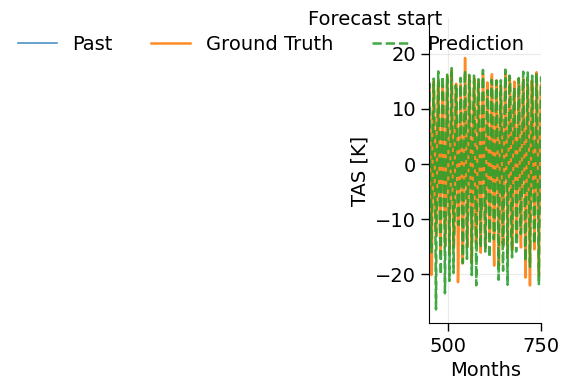

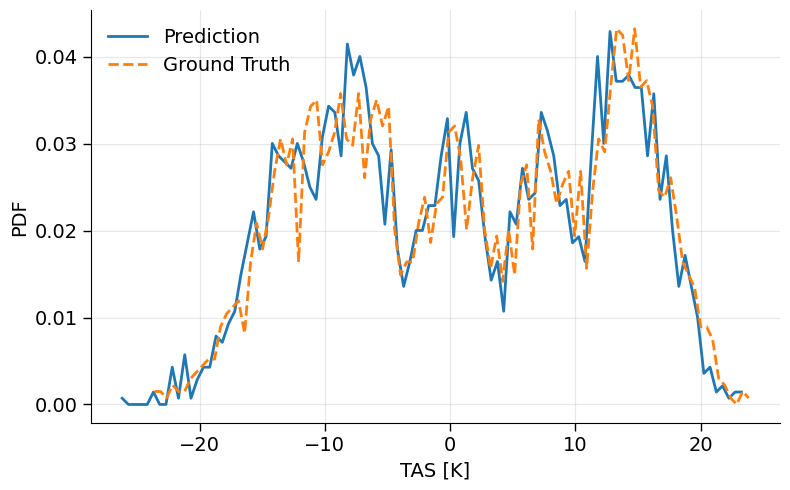

In [11]:
tas_test = test_data_np[:,:regions,:]
tas_test = np.transpose(tas_test,(0, 2, 1))
pr_test = test_data_np[:,-regions:,:]
pr_test = np.transpose(pr_test,(0, 2, 1))
print(len(tas_test[0]))

Tc_test = 120 #shift of 4 months
H =2800

y_past = tas_test[:,:Tc_test,:]
u_past = np.expand_dims(test_gmt[:,:Tc_test],axis=2)
u_future = np.expand_dims(test_gmt[:,Tc_test:Tc_test+H],axis=2)
print("u...", u_future.shape,test_gmt.shape)

# y_past = tas_test[:,-(Tc_test+H):-H,:]
# u_past = np.expand_dims(test_gmt[:,-(Tc_test+H):-H],axis=2)
# u_future = np.expand_dims(test_gmt[:,-H:],axis=2)


y_past_n = y_scaler.transform(y_past)
u_past_n = u_scaler.transform(u_past)
u_future_n = u_scaler.transform(u_future)


y_past_n = torch.tensor(y_past_n,device=device,dtype=torch.float32)
u_past_n = torch.tensor(u_past_n,device=device,dtype=torch.float32)
u_future_n = torch.tensor(u_future_n,device=device,dtype=torch.float32)

        
with torch.no_grad():
    y_mix, y_ssm, y_lin,pr_ssm, score, w = forecast_with_u_fallback(
    model, y_past_n, u_past_n, u_future_n, 
    mu_control, inv_cov_control, 
    tau_ood,
    use_linear_model = use_linear_model,
    n_samples = 1,k=5.0)
y_pred = y_scaler.inverse_transform(y_ssm.cpu().numpy())
pr_pred = pr_scaler.inverse_transform(pr_ssm.cpu().numpy())

pred_data = {
    "tas":y_pred,
    "pr":pr_pred
}

region = region_names.index("EEU")
sample = 0

y_1, x_1 = get_hist_vec(tas_test[sample,Tc_test:Tc_test+H,region], bins=100)
y_2,x_2 = get_hist_vec(y_pred[sample,:,region], bins=100)



#plt.xlim([2300,2500])

# plt.figure()
# plt.plot(np.arange(Tc_test,Tc_test+H),y_pred[sample,:,region])
# plt.plot(np.arange(Tc_test,Tc_test+H),tas_test[sample,-H:,region])
# plt.plot(y_past[sample,:,region])


# t_future = np.arange(Tc_test, Tc_test + H)
# t_past = np.arange(Tc_test - y_past.shape[1], Tc_test)


t_future = np.arange(Tc_test, Tc_test + H)
t_past = np.arange(0, Tc_test)
print(".. ",y_pred.shape,t_future.shape)



plt.figure(figsize=(10, 4))

plt.xlim([450,750])
# Past context
plt.plot(
    t_past,
    y_past[sample, :, region],
    label="Past",
    linewidth=1.2,
    alpha=0.8
)

# Ground truth future
plt.plot(
    t_future,
    tas_test[sample,Tc_test:Tc_test+H, region],
    label="Ground Truth",
    linewidth=1.8,
    alpha=0.9
)

# Prediction
plt.plot(
    t_future,
    y_pred[sample, :, region],
    label="Prediction",
    linewidth=1.8,
    alpha=0.9,
    linestyle="--"
)
plt.tick_params(axis="both", labelsize=14, length=6, width=1)

# Vertical line separating past and forecast horizon
plt.axvline(Tc_test, linestyle=":", linewidth=2)
plt.text(Tc_test + 5, plt.ylim()[1] * 0.95, "Forecast start", fontsize=14)

# Labels and styling
plt.xlabel("Months", fontsize=14)
plt.ylabel("TAS [K]", fontsize=14)
#plt.title("Past Context and Forecast Comparison", fontsize=14)

plt.legend(frameon=False, ncol=3,fontsize=14)
plt.grid(alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()



plt.figure(figsize=(8, 5))

# Estimate bin width (assuming uniform bins)
bin_width_1 = np.diff(x_1).mean()
bin_width_2 = np.diff(x_2).mean()

# Plot bars
# plt.bar(x_1, y_1, width=bin_width_1, alpha=0.5, label="Ground Truth", align="center")
# plt.bar(x_2, y_2, width=bin_width_2, alpha=0.5, label="Prediction", align="center")

plt.plot(x_2, y_2, label="Prediction", linewidth=2)
plt.plot(x_1, y_1, label="Ground Truth", linewidth=2, linestyle="--")
plt.tick_params(axis="both", labelsize=14, length=6, width=1)

# Labels and title
plt.xlabel("TAS [K]", fontsize=14)
plt.ylabel("PDF", fontsize=14)
#plt.title("Distribution of TAS: Prediction vs Ground Truth", fontsize=14)

# Styling
plt.grid(alpha=0.3)
plt.legend(frameon=False,fontsize=14)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# model.eval()
#   with torch.no_grad():
#       # run the emit MLP for one timestep
#       # e_in is whatever you'd normally feed: z_t [B, z_dim] or
#       # cat([z_t, uh_t, s.reshape(B,-1)]) if emission_uses_u=True
#       emit_out = model.emit(e_in)          # [B, y_dim*(2+rank)]
#       res, cov_factor, cov_diag = model._parse_emit(emit_out, B)
#       # cov_factor: [B, y_dim, rank]  — the U matrix
#       # cov_diag:   [B, y_dim]        — diagonal variance

#   To get e_in without re-implementing the full forward pass, the cleanest hook is to run forecast or forward_elbo and register a forward hook on self.emit:
  
captured = {}

def hook(module, input, output):
  B = output.shape[0]
  res, cov_factor, cov_diag = model._parse_emit(output, B)
  captured["cov_factor"] = cov_factor.cpu()   # [B, y_dim, rank]
  captured["cov_diag"]   = cov_diag.cpu()     # [B, y_dim]

handle = model.emit.register_forward_hook(hook)

with torch.no_grad():
  model.forecast(y_past_n, u_past_n, u_future_n, steps=H, n_samples=1)

handle.remove()   # always clean up

# now inspect
U = captured["cov_factor"]   # [B, y_dim, rank]
# implied covariance at that step: U @ U.T + diag(cov_diag)
#Sigma = U @ U.transpose(-1, -2) + torch.diag_embed(captured["cov_diag"])
print(U[-1])

tensor([[ 1.5311e-03,  1.7274e-02, -4.2682e-03,  1.9065e-02,  3.2470e-02],
        [-7.7095e-03,  7.9566e-03,  4.6095e-02, -4.9036e-02, -4.5410e-02],
        [-5.6099e-02,  1.7963e-02, -1.3877e-02, -3.3910e-02, -4.9841e-02],
        [-2.2224e-02,  6.6280e-03, -4.8997e-02, -6.5547e-03, -9.8460e-03],
        [-9.5212e-02, -5.0575e-02, -4.0204e-02, -1.0409e-01,  1.5674e-02],
        [ 1.8427e-02,  2.1761e-03,  4.3430e-02, -2.3348e-02, -7.5439e-03],
        [-1.1510e-02,  4.0078e-05, -2.0578e-03,  1.4883e-02,  6.2557e-03],
        [-9.0967e-03,  2.0063e-03, -1.3518e-02,  9.0750e-03,  3.5228e-02],
        [-2.0170e-02, -5.5899e-05, -5.1836e-03, -8.1450e-03,  8.2513e-03],
        [-7.4093e-02, -4.5535e-02, -5.6716e-02, -9.0919e-02,  2.6852e-02],
        [-1.8662e-03,  1.0293e-02,  3.6456e-03,  9.0537e-04, -1.5228e-02],
        [-1.2407e-02,  2.7099e-03, -1.0276e-02,  7.0346e-03,  6.8606e-03],
        [ 6.2430e-04, -2.0765e-02, -1.7590e-02,  8.9389e-03, -7.3871e-02],
        [ 2.8066e-02, -8.

In [13]:
def get_variability_from_data(n_first_indices,y_gt):
    monthly_data=[]
    for i in range(12):
        monthly_data.append([])
        for j in np.arange(i,n_first_indices,12):
            monthly_data[i].append(y_gt[j])
        
    variability = np.zeros_like(y_gt)
    
    for i in range(12):
        for j in np.arange(i,len(variability),12):
            variability[j]=np.std(np.array(monthly_data[i]))
    return variability

-2.2305811303218746 2.3635417012352447
(40, 3012)


/scratch/slurm/2813221/ipykernel_2372/238235346.py:36: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(y_pred-y_gt), bins=100)
/scratch/slurm/2813221/ipykernel_2372/238235346.py:99: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(pr_pred-pr_gt)


<Figure size 640x480 with 0 Axes>

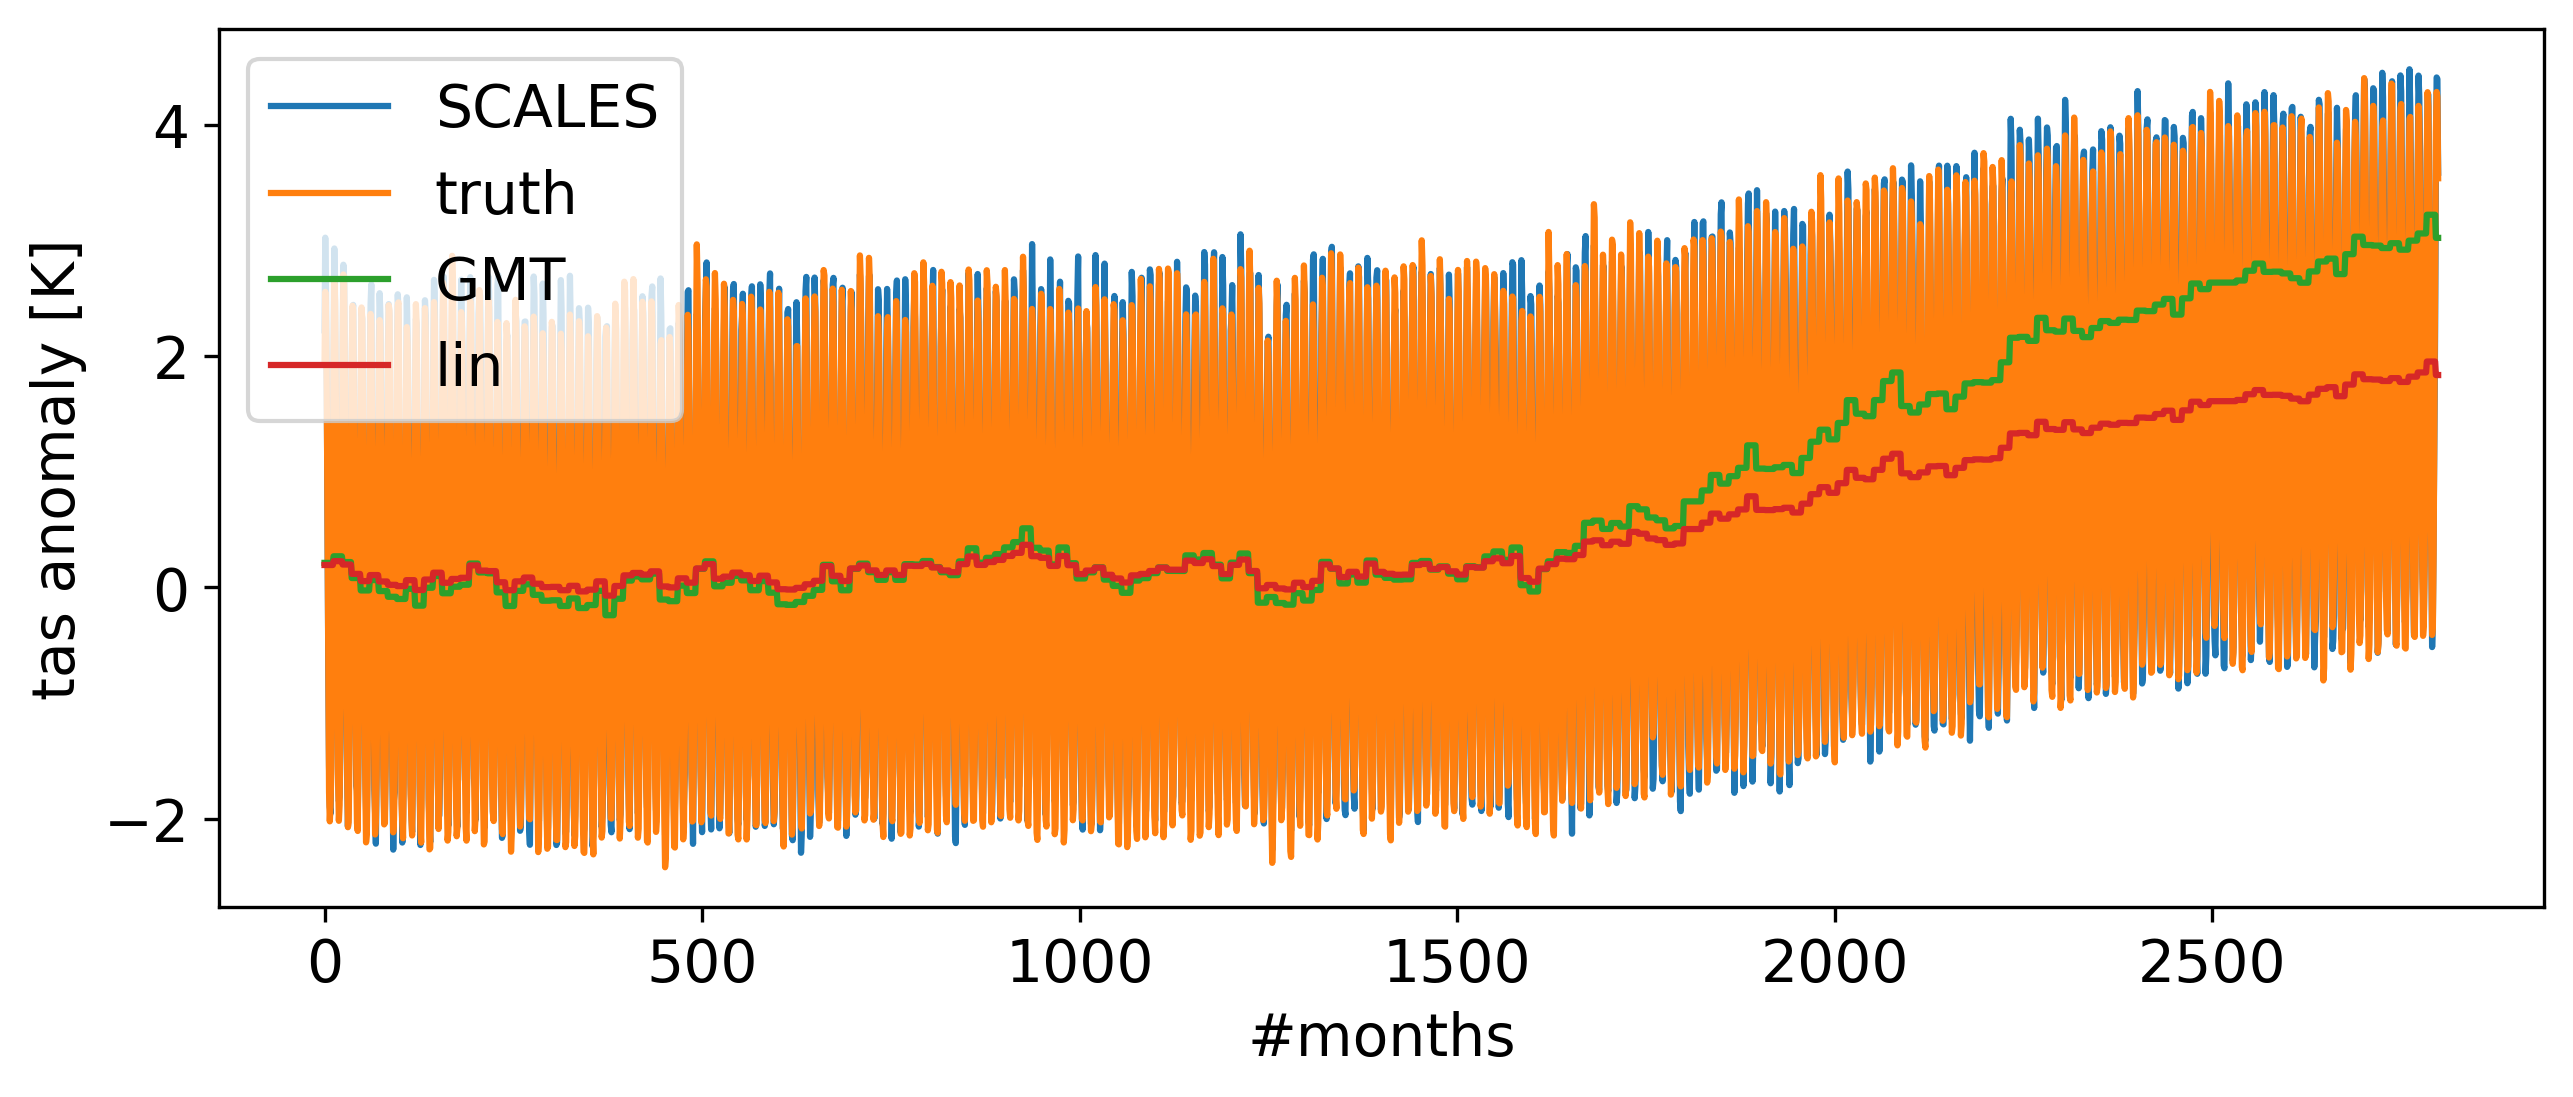

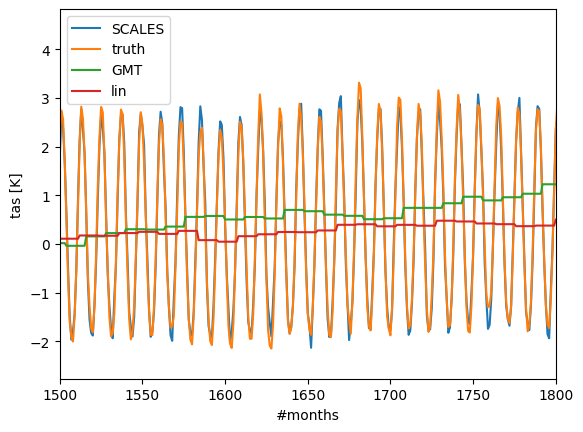

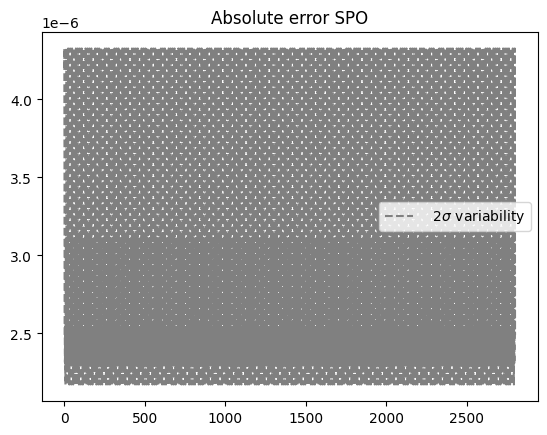

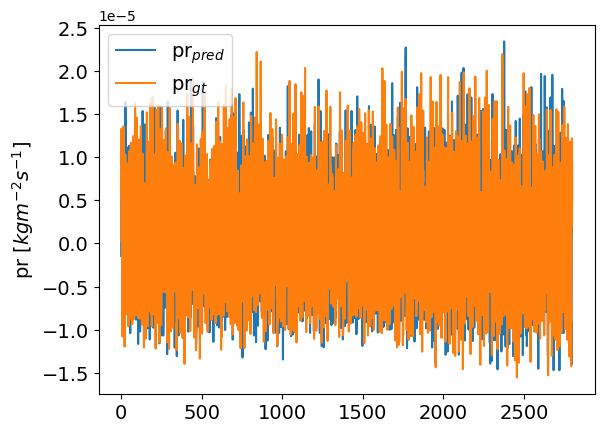

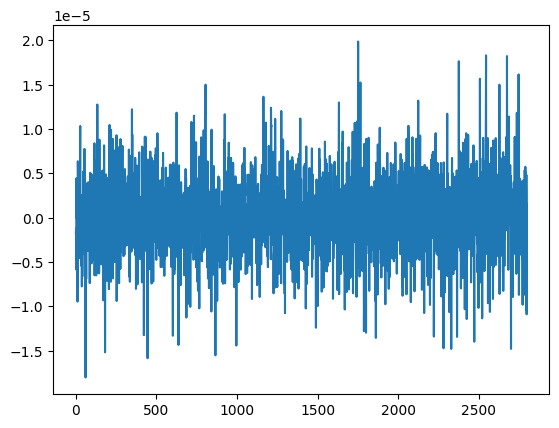

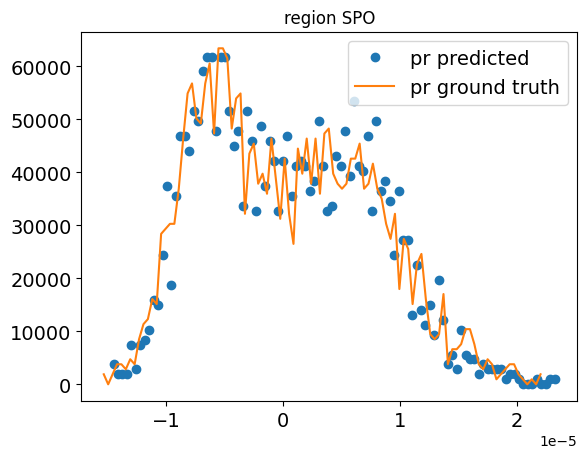

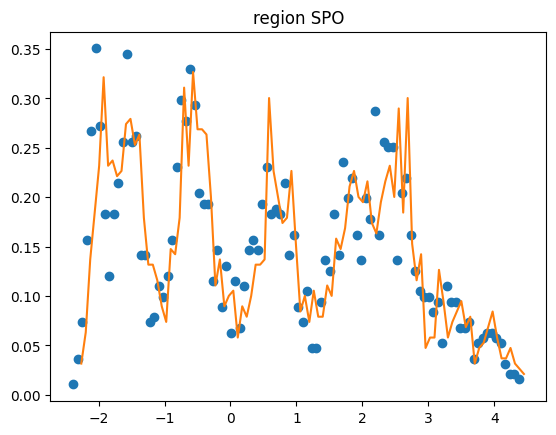

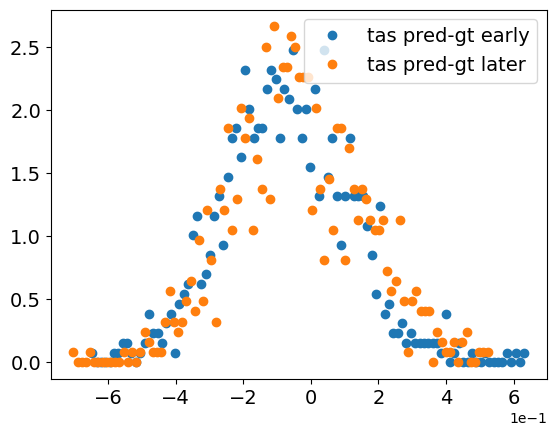

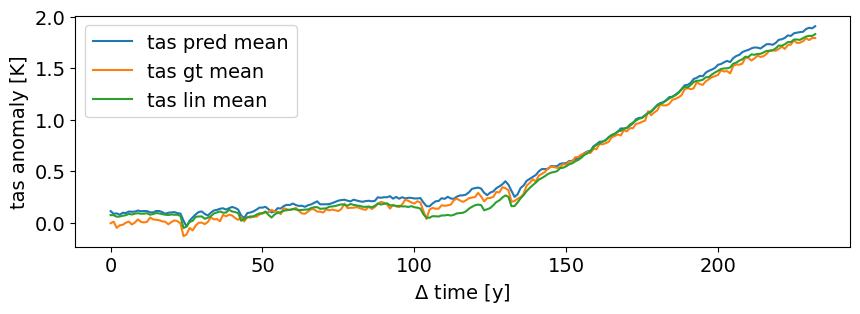

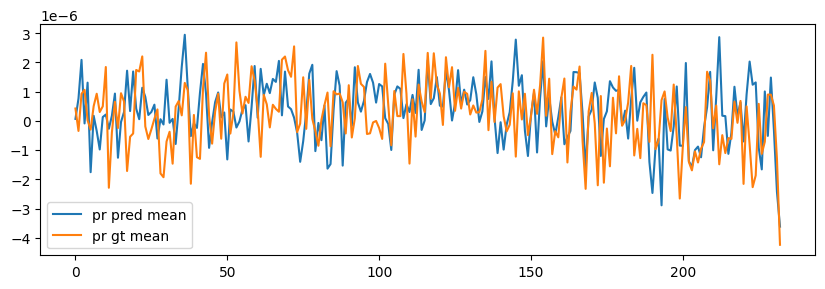

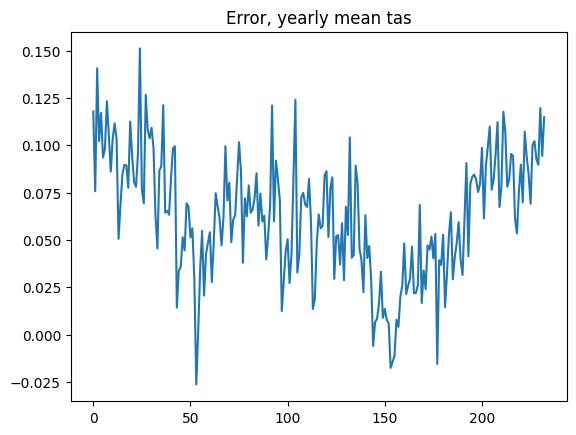

In [14]:
region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB']
sample = 0 #17 bad for pr; 15, 35, 27 for ssp534-over


region = region_names.index("SPO")
region = region
y_pred = y_scaler.inverse_transform(y_ssm.cpu())[sample,:,region]
y_pred_lin = y_scaler.inverse_transform(y_lin.cpu())[sample,:,region]
pr_pred = pr_scaler.inverse_transform(pr_ssm.cpu())[sample,:,region]

y_gt = tas_test[sample,Tc_test:Tc_test+H,region]#y_t_n[0,-H:,region]
pr_gt = pr_test[sample,Tc_test:Tc_test+H,region]

y_gt_mean = np.mean(tas_test[:,Tc_test:Tc_test+H,region],axis=0)#y_t_n[0,-H:,region]
pr_gt_mean = np.mean(pr_test[:,Tc_test:Tc_test+H,region],axis=0)
y_pred_mean = np.mean(y_scaler.inverse_transform(y_ssm.cpu().numpy())[:,:,region],axis =0)
y_pred_lin_mean = np.mean(y_scaler.inverse_transform(y_lin.cpu().numpy())[:,:,region],axis =0)
y_gt_std = np.std(tas_test[:,Tc_test:Tc_test+H,region],axis=0)#y_t_n[0,-H:,region]
y_pred_std = np.std(y_scaler.inverse_transform(y_ssm.cpu().numpy())[:,:,region],axis =0)

variability = get_variability_from_data(400,pr_gt)


y_1, x_1 = get_hist_vec((pr_gt), bins=100)
y_2,x_2 = get_hist_vec((pr_pred), bins=100)
y_3, x_3 = get_hist_vec((y_gt), bins=100)
y_4,x_4 = get_hist_vec((y_pred), bins=100)
y_5, x_5 = get_hist_vec((y_gt[:1000]-y_pred.numpy()[:1000]), bins=100)
y_6,x_6 = get_hist_vec((y_gt[-1000:]-y_pred.numpy()[-1000:]), bins=100)
y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(y_pred-y_gt), bins=100)

pi_period = 300
y_for_normalisation = y_gt[0:pi_period]-y_pred_lin[0:pi_period].cpu().numpy()
y_norm_max = np.percentile(y_for_normalisation,95)
y_norm_min = np.percentile(y_for_normalisation,5)
print(y_norm_min,y_norm_max)
print(test_gmt.shape)

y_yearly_mean = [np.mean(y_pred_mean[i-12:i]) for i in np.arange(12,len(y_pred),12)]
y_yearly_mean_2 = [np.mean(y_pred[i-12:i].numpy()) for i in np.arange(14,len(y_pred),12)]
y_yearly_gt = [np.mean(y_gt_mean[i-12:i]) for i in np.arange(12,len(y_gt),12)]
y_yearly_lin = [np.mean(y_pred_lin_mean[i-12:i]) for i in np.arange(12,len(y_pred_lin),12)]
y_yearly_gt_std = [np.mean(y_gt_std[i-12:i]) for i in np.arange(12,len(y_pred_lin),12)]
y_yearly_std = [np.mean(y_pred_std[i-12:i]) for i in np.arange(12,len(y_pred),12)]
y_yearly_mean = np.array(y_yearly_mean)
y_yearly_gt = np.array(y_yearly_gt)


pr_yearly_mean = [np.mean(pr_pred[i-12:i].numpy()) for i in np.arange(12,len(pr_pred),12)]
pr_yearly_gt = [np.mean(pr_gt[i-12:i]) for i in np.arange(12,len(pr_gt),12)]

#plt.title(f"{TEST_SCENARIOS}, region {region_names[region]}, single sample")
plt.figure(figsize=(10, 3.8), dpi=300)
plt.ylabel("tas anomaly [K]",fontsize=14)
plt.xlabel("#months",fontsize=14)
plt.plot(y_pred, label="SCALES")
plt.plot(y_gt,label="truth")
plt.plot(test_gmt[sample,Tc_test:Tc_test+H],label="GMT")
plt.plot(y_pred_lin,label="lin")
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.figure()
plt.ylabel("tas [K]")
plt.xlabel("#months")
plt.xlim([4800,5000])
plt.xlim([1500,1800])
plt.plot(y_pred,label="SCALES")
plt.plot(y_gt,label="truth")
plt.plot(test_gmt[sample,-H:],label="GMT")
plt.plot(y_pred_lin,label="lin")
plt.legend()
# plt.figure()
# #plt.xlim([1500,2000])
# plt.title("Normalised error")
# plt.plot(((y_pred-y_gt)-y_norm_min)*2./(y_norm_max-y_norm_min)-1.)
plt.figure()
#plt.ylim([-2,2])
plt.title(f"Absolute error {region_names[region]}")
#plt.xlim([0,2000])
#plt.plot(y_pred-y_gt, label = "y$_{pred}$ - y$_{gt}$")
plt.plot(variability,color="grey",ls="--",label = "  $2\sigma$ variability")
#plt.plot(variability*(-2),color = "grey",ls="--")
plt.legend()
plt.figure()
#plt.xlim([2100,2300])
plt.ylabel("pr [$kg m^{-2} s^{-1}$]",fontsize=14)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.plot(pr_pred,label="pr$_{pred}$")
plt.plot(pr_gt,label = "pr$_{gt}$")
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.figure()
plt.plot(pr_pred-pr_gt)
plt.figure()
plt.title(f"region {region_names[region]}")
plt.plot(x_2,y_2, "o",label = "pr predicted")
plt.plot(x_1,y_1, label = "pr ground truth")
plt.tick_params(axis='both', labelsize=14)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend(fontsize=14)
plt.figure()
plt.title(f"region {region_names[region]}")
plt.plot(x_3,y_3,"o",label = "tas pred")
plt.plot(x_4,y_4, label = "tas gt")
plt.figure()
plt.plot(x_5,y_5,"o",label = "tas pred-gt early")
plt.plot(x_6,y_6,"o",label = "tas pred-gt later")
plt.legend()
# plt.plot(x_6,y_6, label = "tas gt - later")
plt.tick_params(axis='both', labelsize=14)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend(fontsize=14)
plt.figure(figsize=(10,3))
plt.xlabel("$\Delta$ time [y]",fontsize=14)
plt.ylabel("tas anomaly [K]",fontsize=14)
plt.plot(y_yearly_mean,label="tas pred mean")
#plt.plot(y_yearly_mean+y_yearly_std,"--",color="black")
#plt.plot(y_yearly_mean-y_yearly_std,"--",color="black")
plt.plot(y_yearly_gt,label = "tas gt mean")
#plt.plot(y_yearly_gt+y_yearly_gt_std,"--",color="grey")
#plt.plot(y_yearly_gt-y_yearly_gt_std,"--",color="grey")
plt.plot(y_yearly_lin,label = "tas lin mean")
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
# plt.xlabel("$\Delta$ time [y]")
# plt.ylabel("tas anomaly [K]")
# plt.plot(y_yearly_mean,label="tas pred mean")
# plt.plot(y_yearly_mean+y_yearly_std,"--",color="black")
# plt.plot(y_yearly_mean-y_yearly_std,"--",color="black")
# plt.plot(y_yearly_gt,label = "tas gt mean")
# plt.plot(y_yearly_gt+y_yearly_gt_std,"--",color="grey")
# plt.plot(y_yearly_gt-y_yearly_gt_std,"--",color="grey")
# plt.plot(y_yearly_lin,label = "tas lin mean")
# plt.legend()
plt.figure(figsize=(10,3))
plt.plot(pr_yearly_mean,label="pr pred mean")
#plt.plot(y_yearly_mean_2,label="predicted mean 2")
plt.plot(pr_yearly_gt,label = "pr gt mean")
plt.legend()
plt.figure()
plt.title("Error, yearly mean tas")
plt.plot(y_yearly_mean - y_yearly_gt)

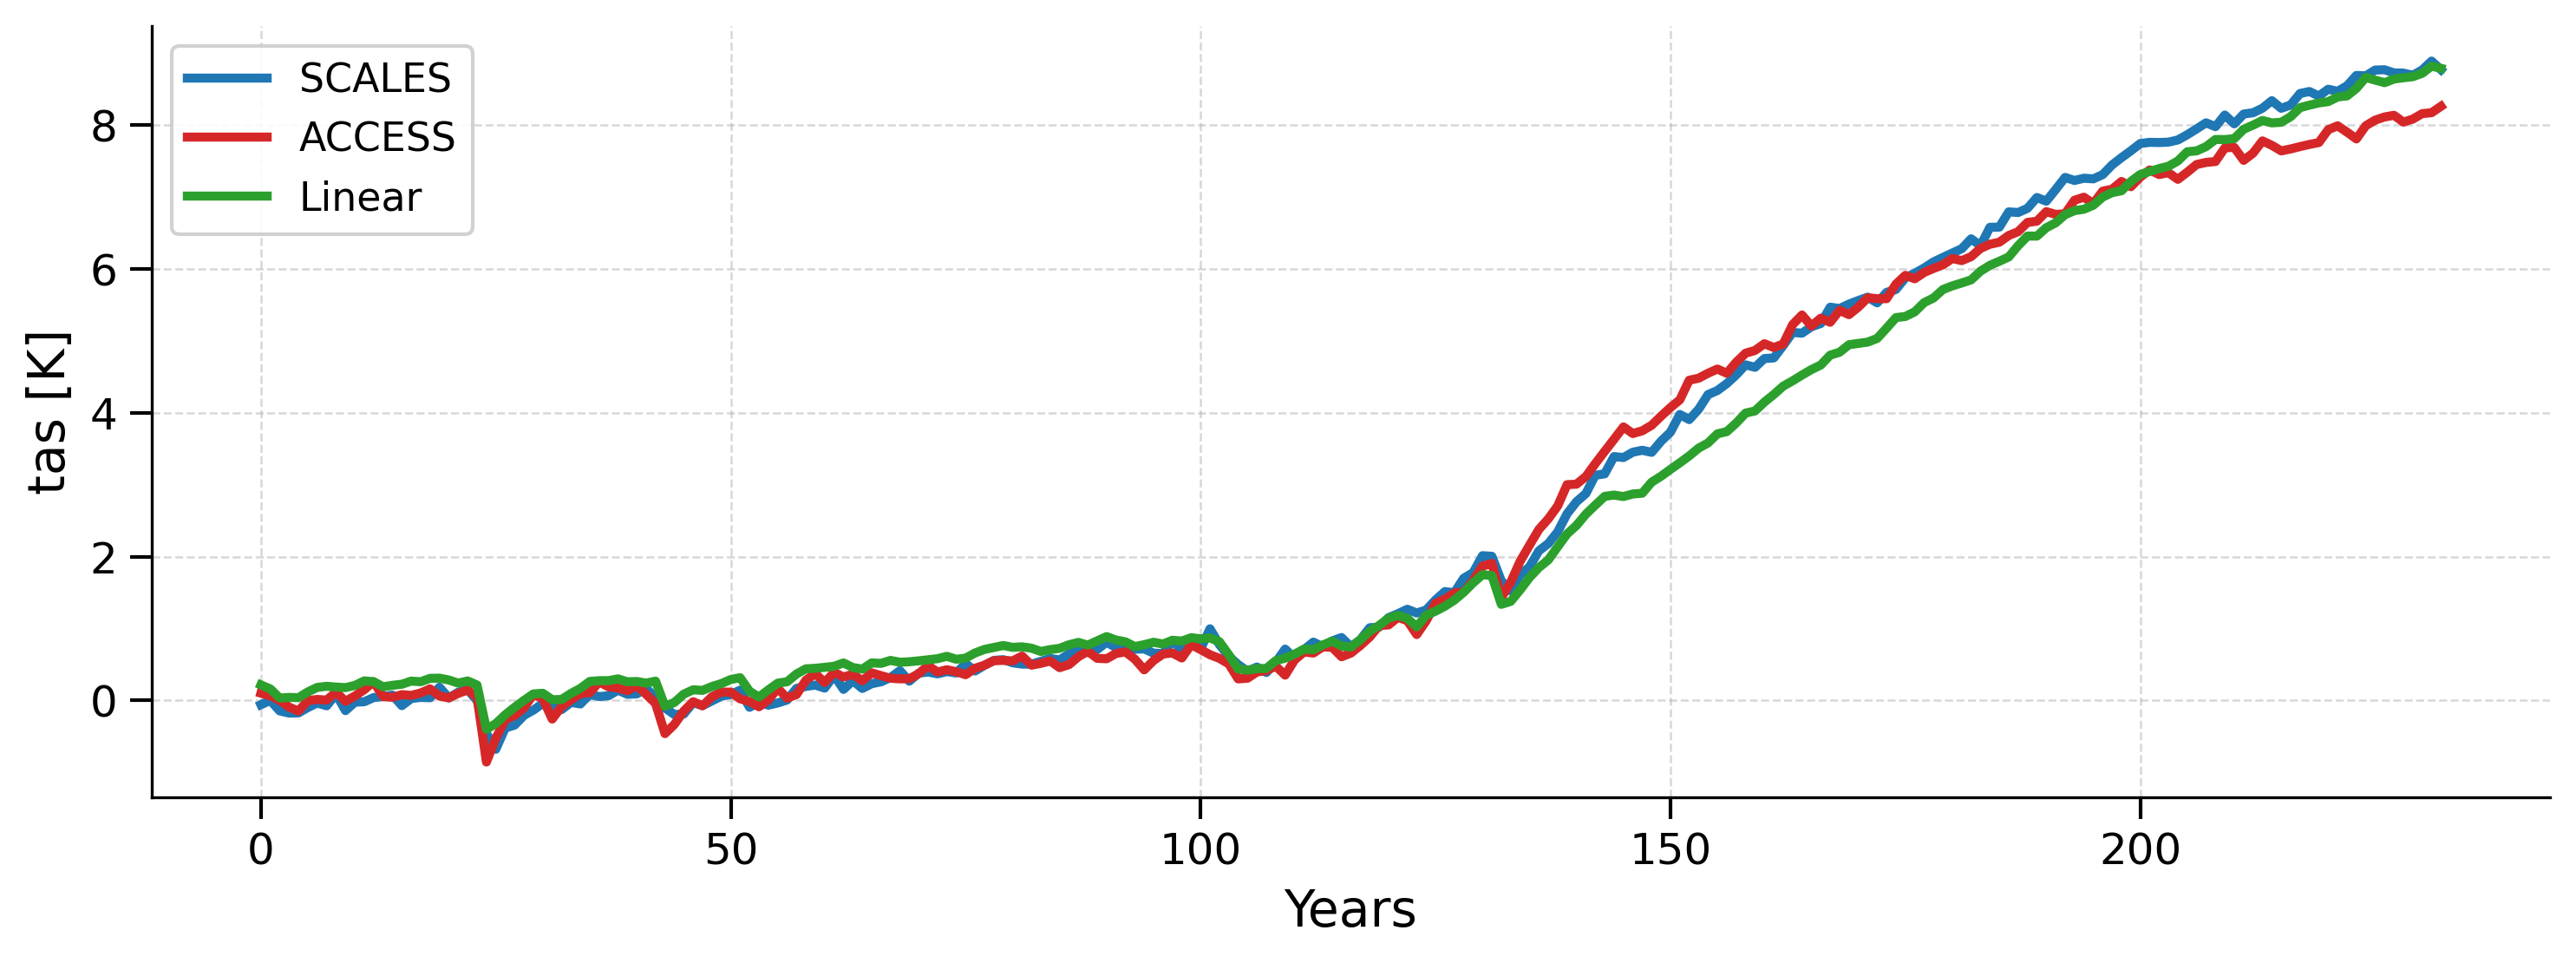

In [33]:
plt.figure(figsize=(10, 3.8), dpi=300)

# Professional muted color palette
plt.plot(
    y_yearly_mean,
    label="SCALES",
    linewidth=2.5,
    color="#1f77b4"   # deep blue
)

plt.plot(
    y_yearly_gt,
    label="ACCESS",
    linewidth=2.5,
    color="#d62728"   # muted red
)

plt.plot(
    y_yearly_lin,
    label="Linear",
    linewidth=2.5,
    color="#2ca02c"   # professional green
)

# Labels
plt.xlabel(r"Years", fontsize=14)
plt.ylabel("tas [K]", fontsize=14)

# Tick styling
plt.tick_params(axis="both", labelsize=12, length=6, width=1)

# Subtle grid for publication-quality appearance
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

# Cleaner legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="0.8",
    loc="best"
)

# Remove top/right spines for modern scientific style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout for clean spacing
plt.tight_layout()
#plt.savefig("/home/kainverena/PythonProjects/scales_plots/soo_ssp126_30Apr26_yearly_reservoir_no_hidden.pdf")

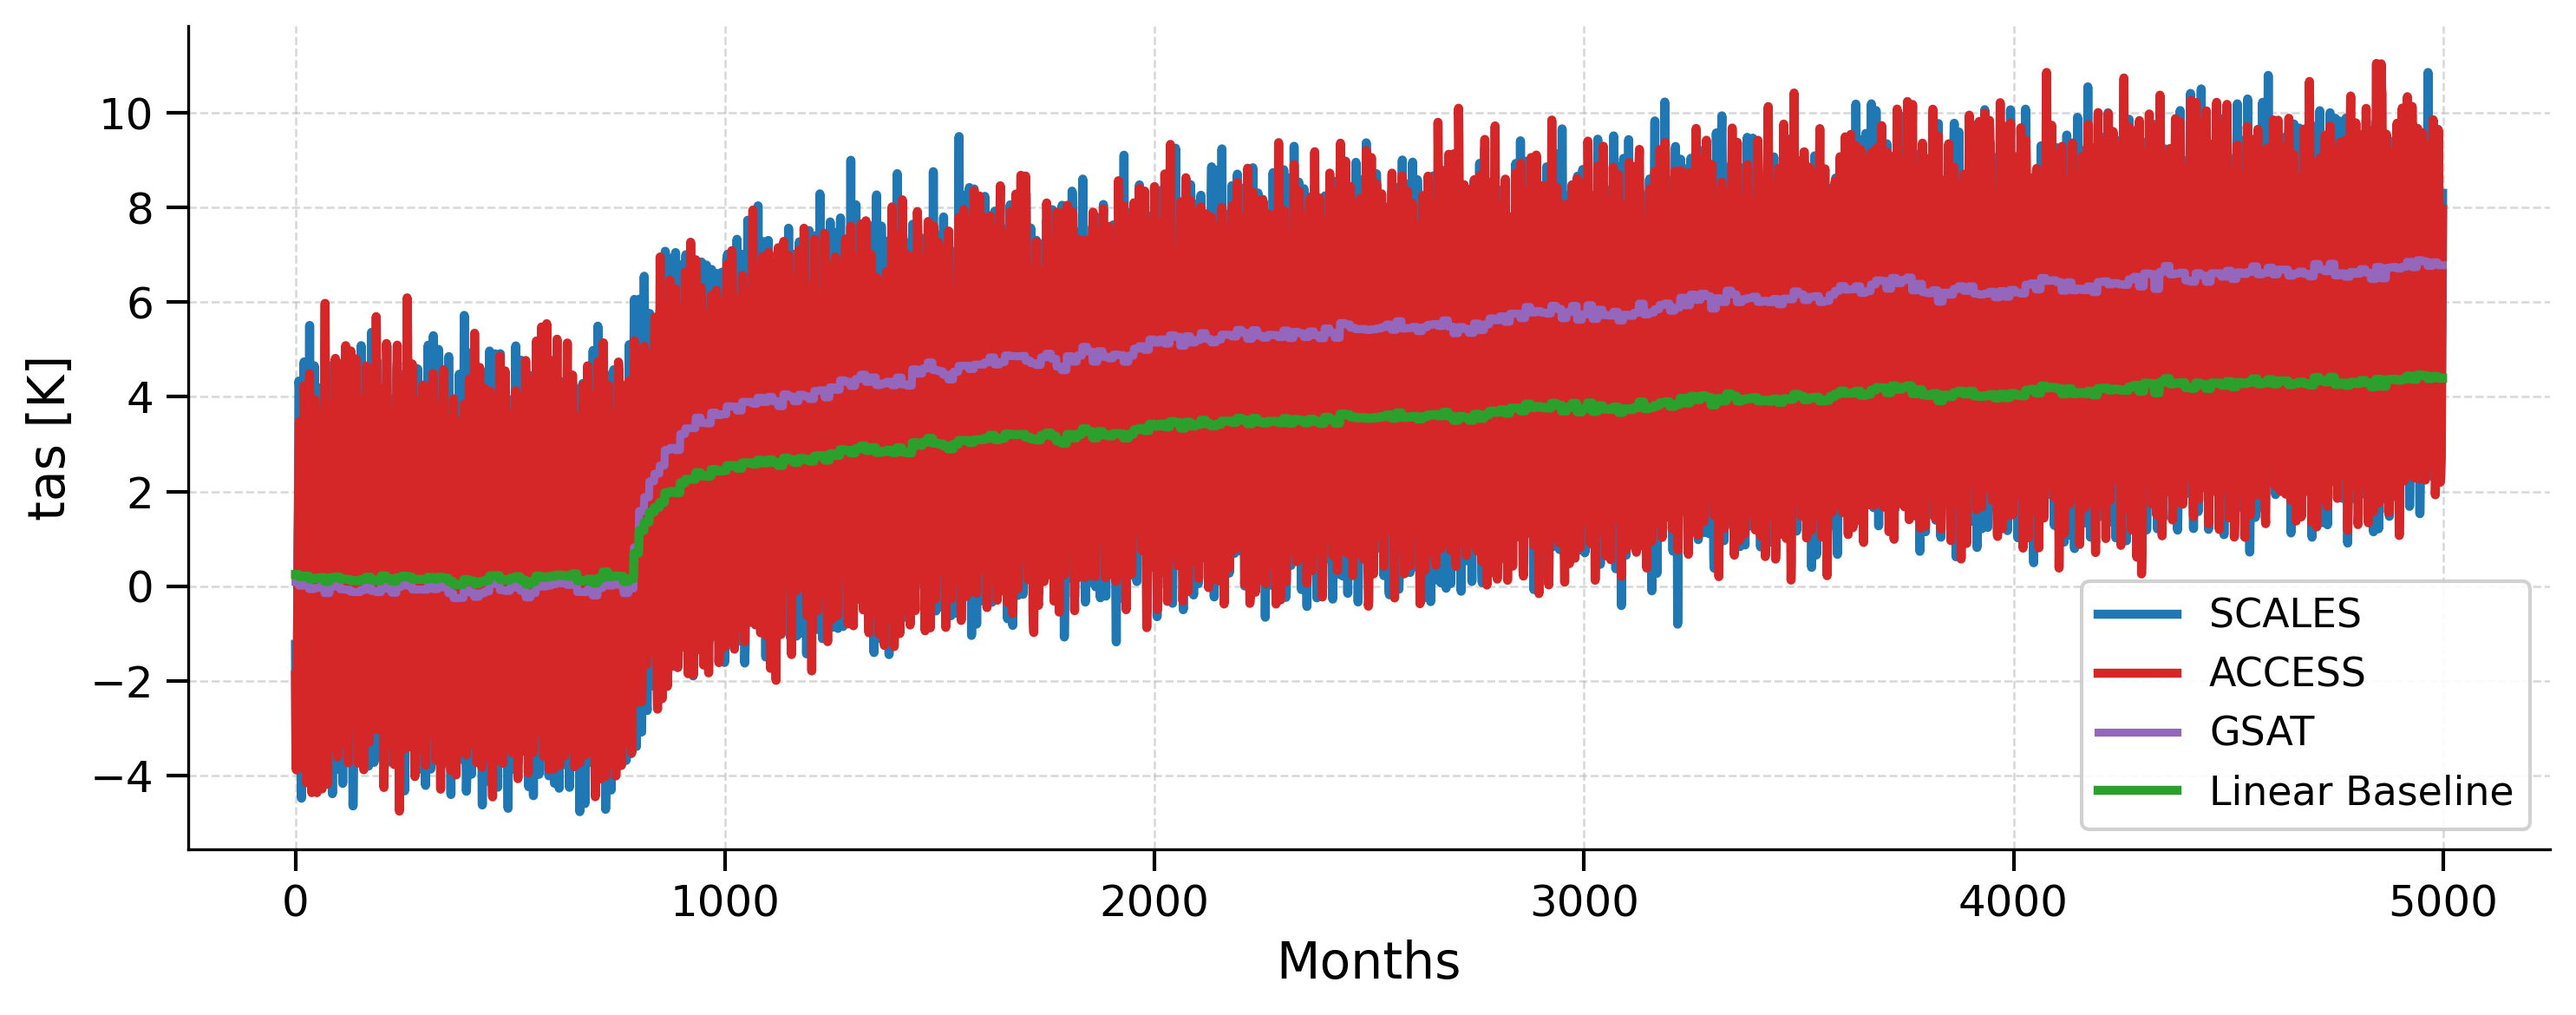

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4), dpi=300)

# Professional scientific color palette
plt.plot(
    y_pred,
    label="SCALES",
    linewidth=2.5,
    color="#1f77b4"   # deep blue
)

plt.plot(
    y_gt,
    label="ACCESS",
    linewidth=2.5,
    color="#d62728"   # muted red
)

plt.plot(
    test_gmt[sample, -H:],
    label="GSAT",
    linewidth=2.2,
    color="#9467bd"   # professional purple
)

plt.plot(
    y_pred_lin,
    label="Linear Baseline",
    linewidth=2.5,
    color="#2ca02c"   # muted green
)
#plt.xlim([4800,5000])
# Axis labels
plt.xlabel("Months", fontsize=14)
plt.ylabel("tas [K]", fontsize=14)

# Tick styling
plt.tick_params(
    axis="both",
    labelsize=12,
    length=6,
    width=1
)

# Subtle publication-style grid
plt.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

# Clean legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="0.8",
    loc="best"
)

# Remove unnecessary spines for cleaner appearance
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Improve spacing
plt.tight_layout()
#plt.savefig("/home/kainverena/PythonProjects/scales_plots/sau_abrupt4c02_30Apr26.pdf")
plt.show()

In [14]:
Generation of ensemble data

(40, 3012, 58) (40, 3012)
(40, 2880, 1)


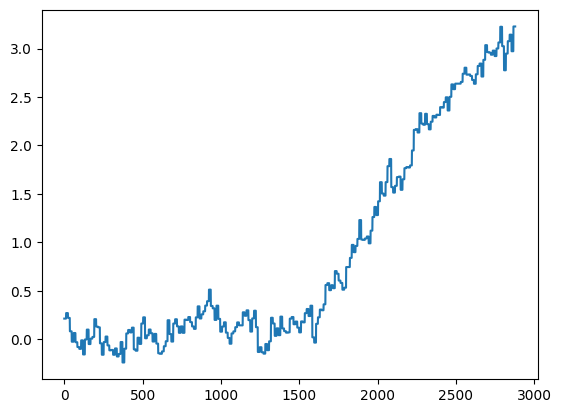

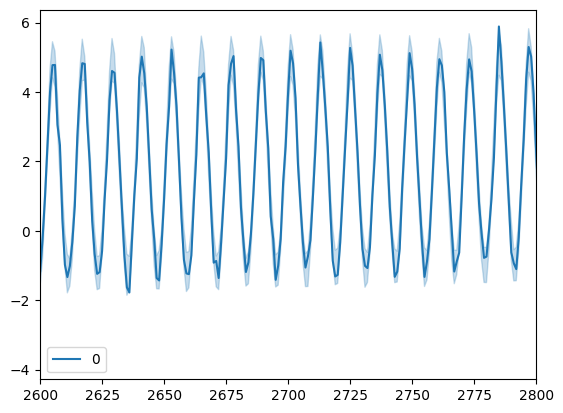

In [17]:
tas_test = test_data_np[:,:regions,:]
tas_test = np.transpose(tas_test,(0, 2, 1))
pr_test = test_data_np[:,-regions:,:]
pr_test = np.transpose(pr_test,(0, 2, 1))
print(tas_test.shape,test_gmt.shape)


Tc_test = 120
H = 2880

#y_past = tas_test[:,-(Tc_test+H):-H,:]
y_past = tas_test[:,:Tc_test,:]
#u_past = np.expand_dims(test_gmt[:,-(Tc_test+H):-H],axis=2)
u_past = np.expand_dims(test_gmt[:,:Tc_test],axis=2)
#u_future = np.expand_dims(test_gmt[:,-H:],axis=2)
u_future = np.expand_dims(test_gmt[:,Tc_test:(Tc_test+H)],axis=2)

plt.plot(u_future[0,:,0])

y_past_n = y_scaler.transform(y_past)
u_past_n = u_scaler.transform(u_past)
u_future_n = u_scaler.transform(u_future)
print(u_future.shape)

y_past_n = torch.tensor(y_past_n,device=device,dtype=torch.float32)
u_past_n = torch.tensor(u_past_n,device=device,dtype=torch.float32)
u_future_n = torch.tensor(u_future_n,device=device,dtype=torch.float32)

# n_samples = 40

# y_pred_ensemble = []
# pr_pred_ensemble = []
# for i in range(n_samples):
        
with torch.no_grad():
    y_mix, y_ssm, y_lin,pr_ssm, score, w = forecast_with_u_fallback(
    model, y_past_n, u_past_n, u_future_n, 
    mu_control, inv_cov_control, 
    tau_ood, 
    n_samples = 1,k=5.0)
y_pred = y_scaler.inverse_transform(y_ssm.cpu().numpy())
pr_pred = pr_scaler.inverse_transform(pr_ssm.cpu().numpy())
#y_pred_ensemble.append(y_pred)
#pr_pred_ensemble.append(pr_pred)
# y_pred_ensemble = np.array(y_pred_ensemble) #dim = n_samples,H,n_regions
# pr_pred_ensemble = np.array(pr_pred_ensemble)
pred_data = {
    "tas":y_pred,
    "pr":pr_pred
}


# print(y_pred.shape)
# region = 1
# plt.figure()
# plt.xlim([0,300])
# #plt.xlim([2300,2500])
# plt.plot(np.arange(Tc_test,Tc_test+H),y_pred[15,:,region])
# plt.plot(np.arange(Tc_test,Tc_test+H),tas_test[15,Tc_test:Tc_test+H,region])
# plt.plot(y_past[15,:,region])


# import pickle
# pickle_filename = "/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/ACCESS/ssp245/ssp245_ens40_pr_tas_monthly_2880m_correlated_rank5_21Jul26.pkl"
# pickle.dump(pred_data, open(pickle_filename, "wb"))

import pickle
pickle_filename = "/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/ACCESS/ssp245/ssp245_ens40_pr_tas_monthly_2880m_correlated_rank5_21Jul26.pkl"
pred_data = pickle.load( open(pickle_filename, "rb") ) 



region = region_names.index("SOO")
sigma = np.std(pred_data["tas"][:,:,region],axis = 0)
mean =  np.mean(pred_data["tas"][:,:,region],axis = 0)

#pr_gt = pr_true[0,-H:,region]



plt.figure()
plt.xlim([2600,2800])
#plt.plot(pred_data["pr"][39,:,region]+sigma,ls="--",color="grey")
#plt.plot(pred_data["pr"][39,:,region]-sigma,ls="--",color="grey")
#plt.plot(pred_data["tas"][39,:,region],color="black")
# plt.plot(pred_data["tas"][15,:,region],label="15")
# #plt.plot(tas_test[15,-H:,region],label="gt")
# plt.plot(pred_data["tas"][8,:,region],label="8")
# plt.plot(pred_data["tas"][12,:,region],label="12")
# plt.plot(pred_data["tas"][25,:,region],label="25")
# plt.plot(pred_data["tas"][30,:,region],label="30")
plt.plot(pred_data["tas"][0,:,region],label="0")
#plt.plot(pr_gt)
plt.fill_between(
    np.arange(0,len(pred_data["tas"][0,:,region]),1),
    mean-2*sigma,
    mean+2*sigma,
    color="tab:blue",
    alpha=0.25,
    #label="10–90% interval",
)
plt.legend()
